### QUESTÃO 2



Um sistema prático e simples para remoção de ruído em sistemas eletrônicos consiste no filtro de
 média móvel. O filtro de média móvel é descrito pela seguinte equação diferença:

$$
y[n] = \frac{1}{M} \sum_{k=0}^{M-1} x[n - k]
$$

 Em que M é a ordem do filtro de média móvel. Diante disso:

## A)

<small> Obtenha, de forma analítica, a expressão para a resposta em frequência de um filtro de média móvel de ordem N = 3. Plote a resposta em frequência desse filtro em Python ou em Matlab. Analisando a resposta em frequência do sistema, o filtro em questão é de que tipo (Passa-Altas, Passa-Baixas, Passa-Faixa ou Rejeita-Faixa)?

Resposta em frequência do filtro de maneira recursiva:

$$ y[n] = h[n]
$$
$$
x[n] = δ[n]
$$
A equação fica:

$$
\ h[n] = \frac{1}{3}(δ[n] + δ[n-1] + δ[n-2])
$$


$$
\ H(e^{jω}) = \sum\limits_{n=-∞}^∞ h[n]e^{-jω}
$$

Expandindo:

$$
\ H(e^{jω}) = \sum\limits_{n=-∞}^∞ [δ[n]+δ[n-1]+δ[n-2]]e^{-jω}
$$

$$
\ H(e^{jω}) = \sum\limits_{n=-∞}^∞ δ[n]e^{-jω}+\sum\limits_{n=-∞}^∞δ[n-1]e^{-jω}+\sum\limits_{n=-∞}^∞δ[n-2]e^{-jω}
$$

Usando a propriedade do impulso temos:


$$
H(e^{j\omega}) = \frac{1}{3} (1 + e^{-j\omega} + e^{-j2\omega})
$$

</small>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


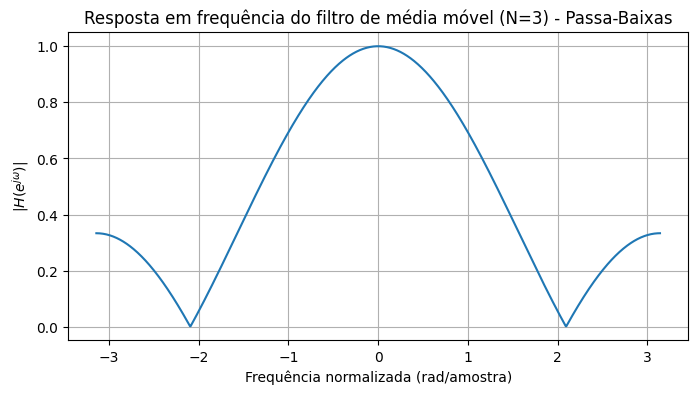

In [6]:
# Ordem do filtro
N = 3
omega = np.linspace(-np.pi, np.pi, 1000)

# Resposta em frequência analítica
H = (1/N) * (1 + np.exp(-1j*omega) + np.exp(-2j*omega))

# Magnitude
H_mag = np.abs(H)

plt.figure(figsize=(8,4))
plt.plot(omega, H_mag)
plt.title('Resposta em frequência do filtro de média móvel (N=3) - Passa-Baixas')
plt.xlabel('Frequência normalizada (rad/amostra)')
plt.ylabel('$|H(e^{jω})|$')
plt.grid(True)
plt.show()


<small>

O gráfico acima mostra que:
- O filtro possui ganho máximo em **frequência zero (DC)**.
- À medida que a frequência aumenta, a resposta vai diminuindo.
- Em torno de ω = π ocorre uma atenuação forte.

Isso é o comportamento característico de um **Filtro Passa-Baixas**.
</small>

## B)

Implemente o filtro de média móvel de ordem 10 em Python ou em Matlab. Para testes, gere um sinal de entrada como segue:
$$x[n] = r[n] + η[n]$$

sendo:
$$r[n] = sin(0.1πn)$$

um sinal senoidal e η[n] um ruído Gaussiano Branco com variância $σ^2$ e média zero.

Apresente os gráficos referentes:

i) ao sinal r[n],

ii) ao sinal de ruído η[n],

iii) ao sinal x[n],

iv) o sinal após a filtragem de média móvel.

v) o erro absoluto entre o sinal r[n] e o sinal filtrado, definido como: $e[n] = |r[n] - y[n]|$

vi) O erro quadrático médio, definido como:

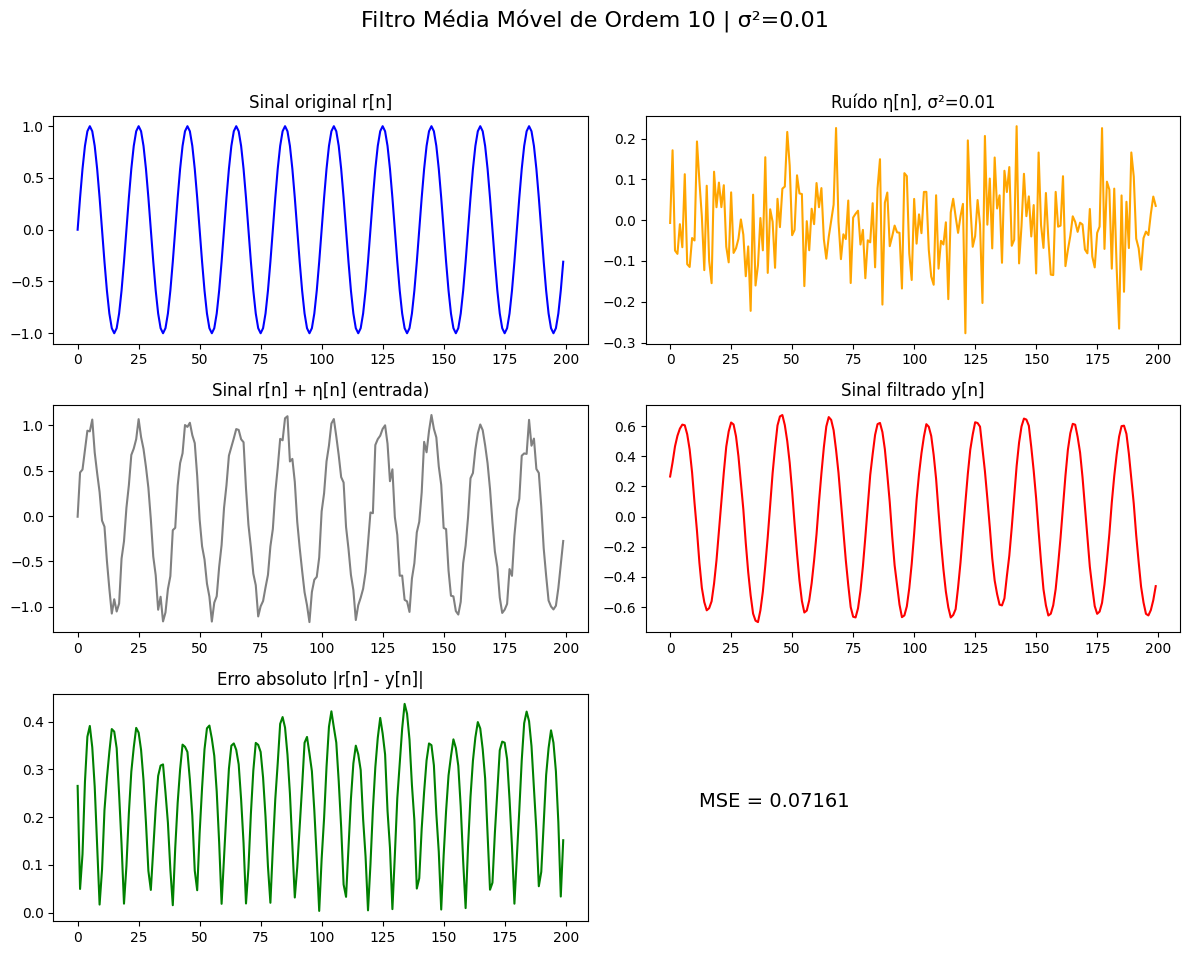

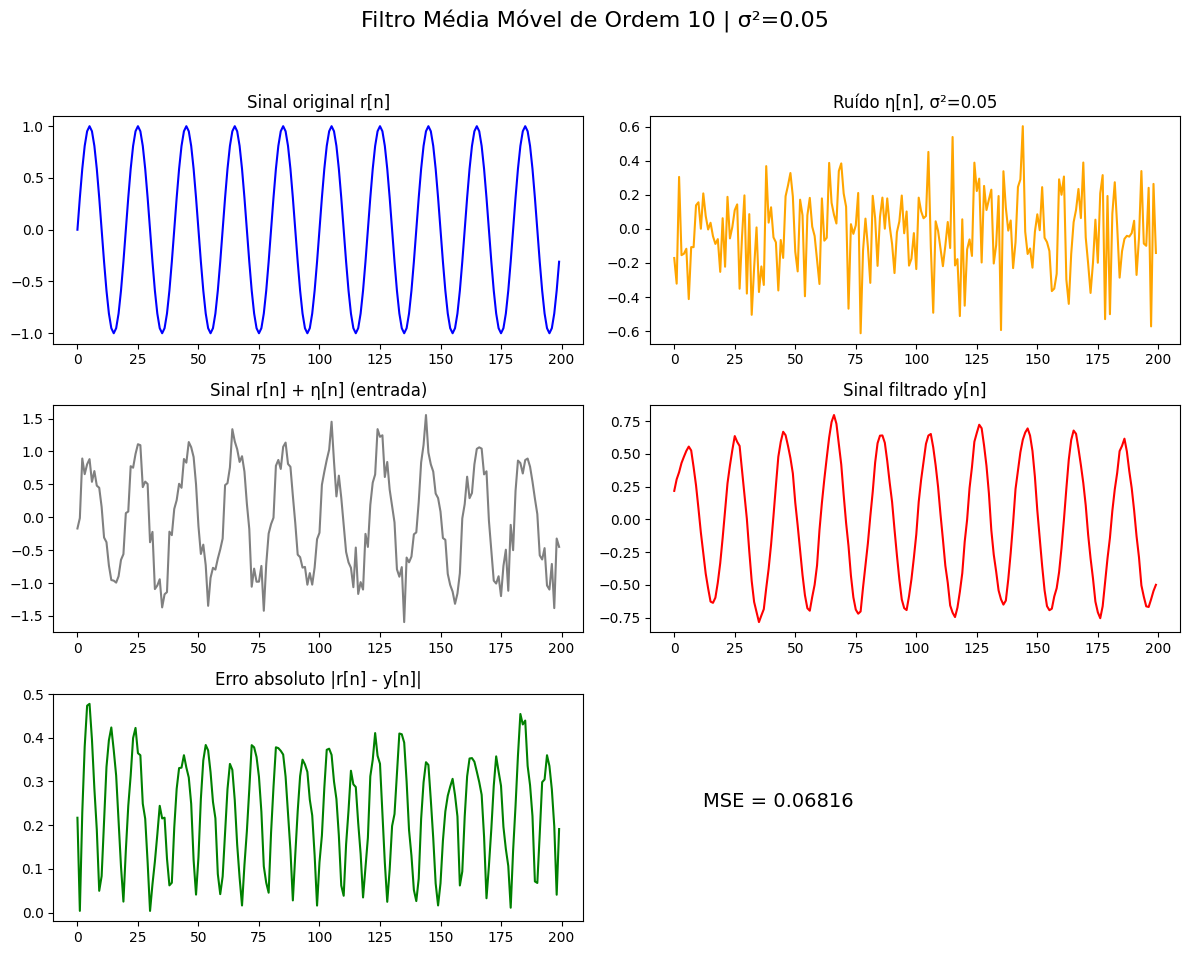

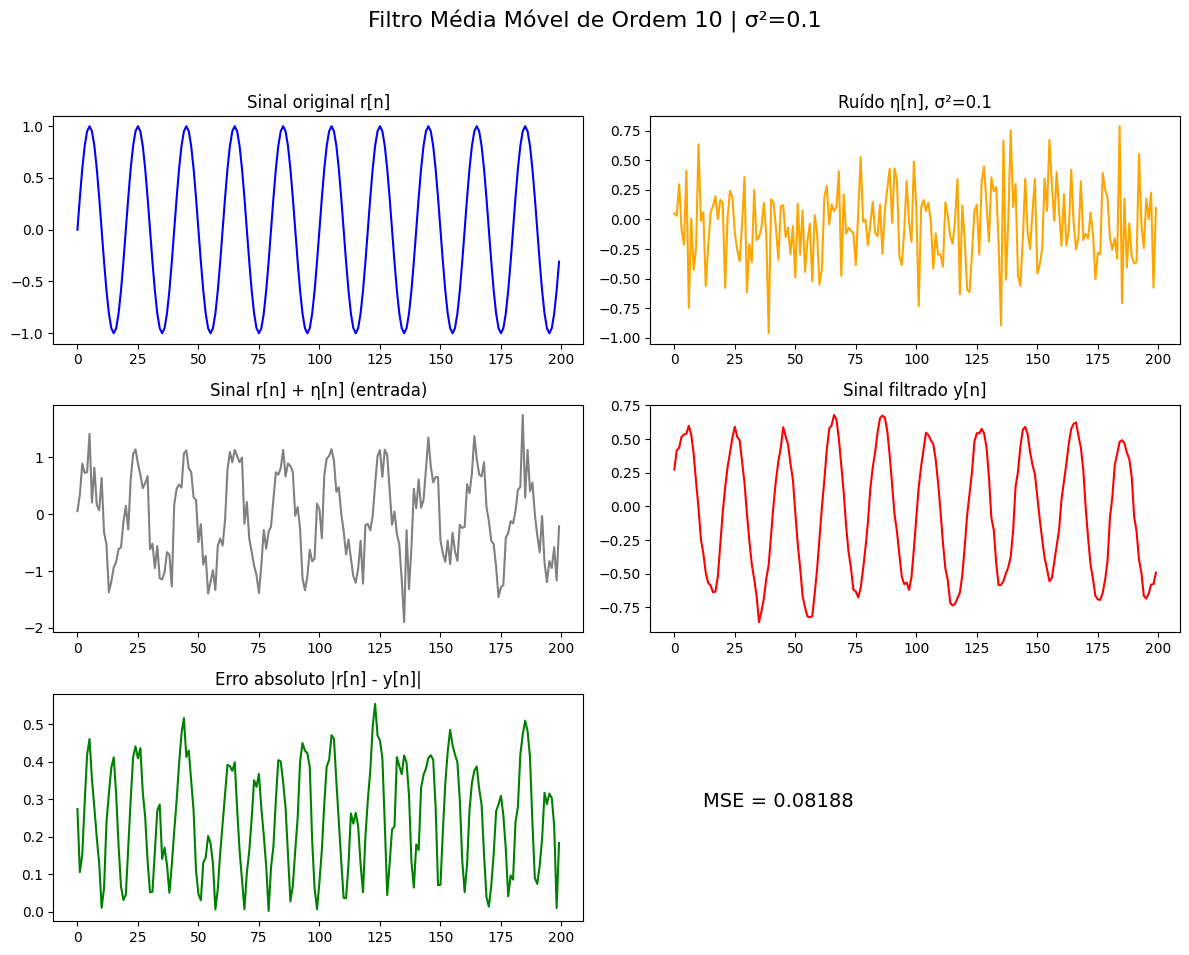

In [9]:
# Parâmetros
N = 200
n = np.arange(N)
M = 10  # ordem do filtro

# Frequências de teste do ruído
sigma_values = [0.01, 0.05, 0.1]

# Criar filtro de média móvel
h = np.ones(M)/M

for sigma in sigma_values:
    # --- Sinais ---
    r = np.sin(0.1*np.pi*n)                  # sinal senoidal
    eta = np.random.normal(0, np.sqrt(sigma), N)  # ruído gaussiano - (média, desvio padrão, tamanho)
    x = r + eta                               # sinal observado

    # --- Filtragem ---
    y = np.convolve(x, h, mode='same')

    # --- Erro ---
    e = np.abs(r - y)
    MSE = np.mean((r - y)**2)


    # --- Plots ---
    plt.figure(figsize=(12,10))

    plt.subplot(3,2,1)
    plt.plot(n, r, 'b')
    plt.title('Sinal original r[n]')

    plt.subplot(3,2,2)
    plt.plot(n, eta, 'orange')
    plt.title(f'Ruído η[n], σ²={sigma}')

    plt.subplot(3,2,3)
    plt.plot(n, x, 'gray')
    plt.title('Sinal r[n] + η[n] (entrada)')

    plt.subplot(3,2,4)
    plt.plot(n, y, 'r')
    plt.title('Sinal filtrado y[n]')

    plt.subplot(3,2,5)
    plt.plot(n, e, 'g')
    plt.title('Erro absoluto |r[n] - y[n]|')

    plt.subplot(3,2,6)
    plt.axis('off')
    plt.text(0.1,0.5,f'MSE = {MSE:.5f}', fontsize=14)

    plt.suptitle(f'Filtro Média Móvel de Ordem {M} | σ²={sigma}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## D)
A distorção devido ao ruído ocorreu devido mais para as variâncias 0,01 e 0,1, enquanto houve redução do MSE para variância 0,05. Isso indica que o desempenho do filtro variou conforme o nível de ruído, apresentando melhor adaptação para a variância intermediária. Já para níveis muito baixos ou mais altos de ruído, o erro médio quadrático aumentou, indicando menor eficiência na recuperação do sinal original.

E)

Repita o item (b) para um filtro com ordem 5 e com ordem 50. Qual a influência da ordem do filtro na performance do sistema?

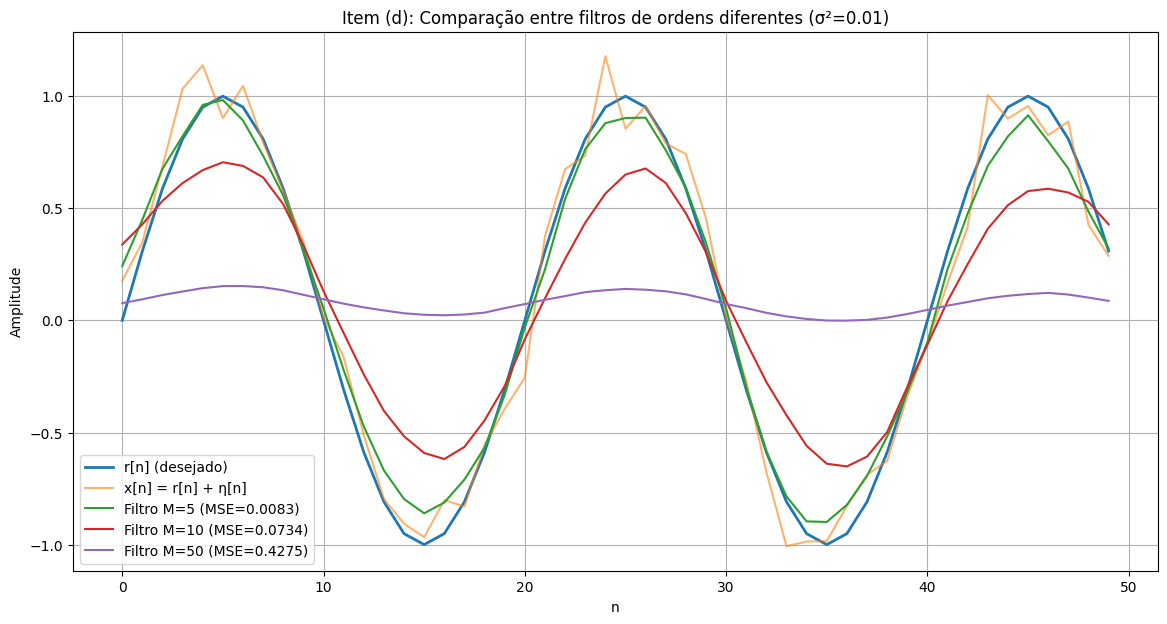

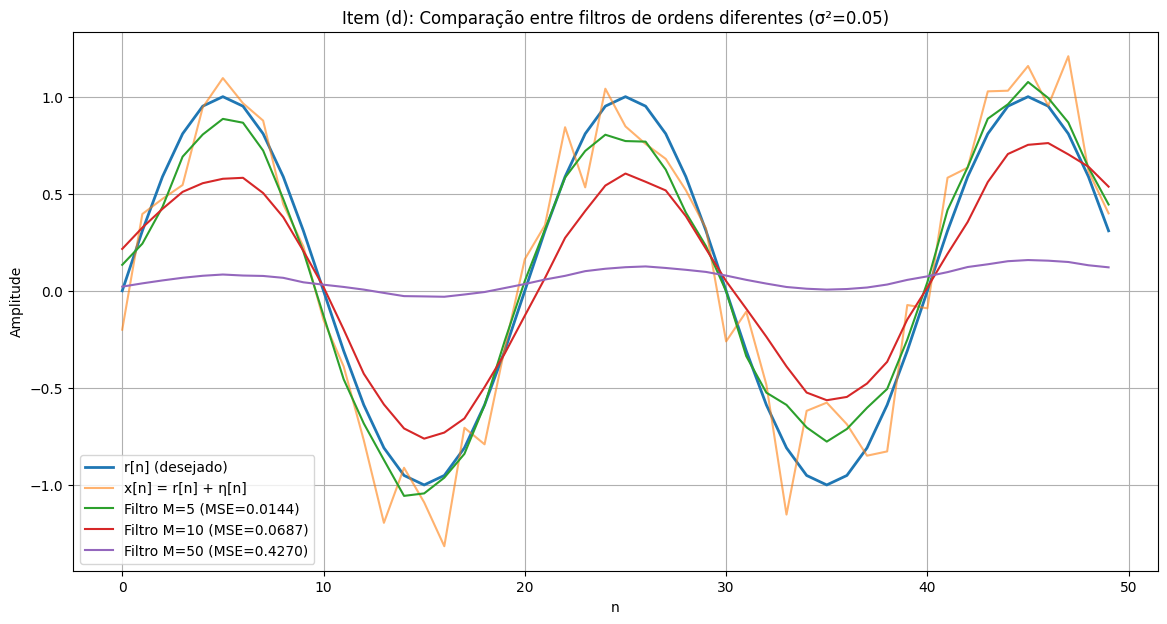

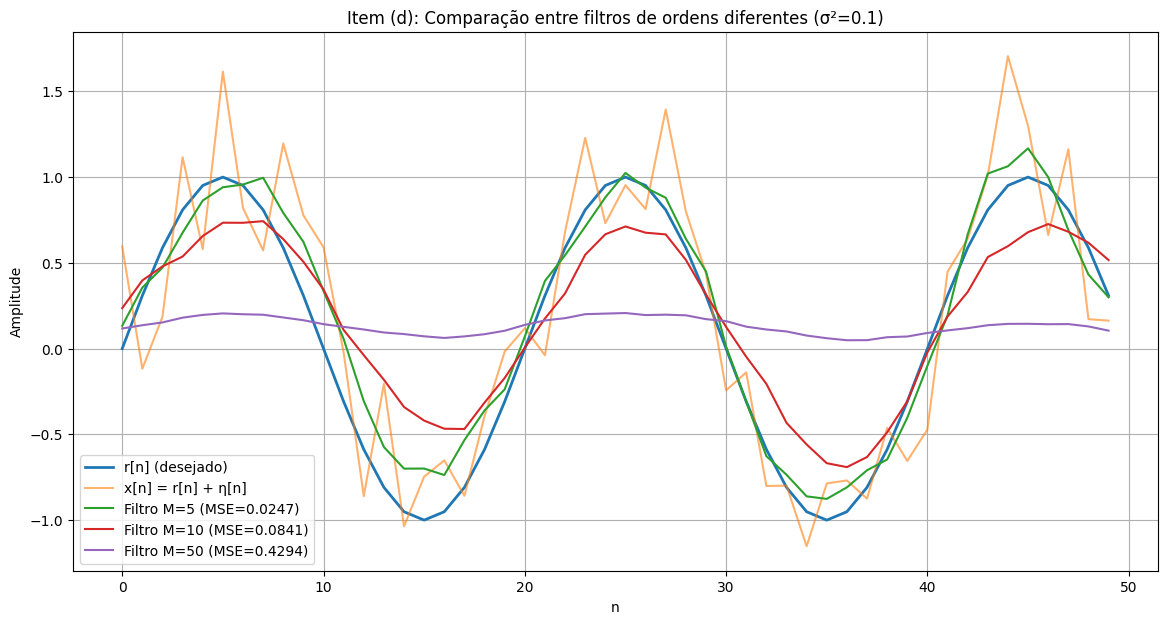

In [8]:
np.random.seed(0)

# Parâmetros
N = 50
n = np.arange(N)
omega0 = 0.1*np.pi
r = np.sin(omega0*n)

# Variância fixa
sigma2_v = [0.01, 0.05, 0.1]

# Ordens do filtro
Ms = [5, 10, 50]
# Ms = [5, 50]

for sigma2 in sigma2_v:
    eta = np.random.normal(0, np.sqrt(sigma2), size=N)
    x = r + eta

    plt.figure(figsize=(14,7))
    plt.plot(n, r, label='r[n] (desejado)', linewidth=2)
    plt.plot(n, x, label='x[n] = r[n] + η[n]', alpha=0.6)
    MSEs = {}

    for M in Ms:
        h = np.ones(M)/M
        y = np.convolve(x, h, mode='same')
        MSEs[M] = np.mean((r-y)**2)
        plt.plot(n, y, label=f'Filtro M={M} (MSE={MSEs[M]:.4f})')

    plt.title(f'Item (d): Comparação entre filtros de ordens diferentes (σ²={sigma2})')
    plt.xlabel('n')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.legend()
    plt.show()


<small>

Os resultados mostram:

- **M = 5**  
  - Suaviza um pouco o ruído, mas ainda deixa bastante flutuação.  
  - Preserva bem o sinal → baixo bias.

- **M = 10**  
  - Bom compromisso entre reduzir ruído e manter o formato do sinal.  
  - Geralmente fornece o **melhor MSE** entre os três.

- **M = 50**  
  - Remove muito ruído (grande suavização).  
  - MAS atenua o sinal desejado (bias elevado).  
  - O MSE piora por conta dessa distorção.


A ordem do filtro controla o compromisso:

- **Ordem baixa → pouca suavização** (ruído residual alto)
- **Ordem muito alta → suavização demais** (atenua o sinal)
- **Existe um M ótimo**, para o sinal e ruído escolhidos.

Aqui, o melhor compromisso foi próximo de **M = 10**.

</small>